# 03 - Evaluate Recall@K

## 1. Import libraries and define paths

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import matplotlib.pyplot as plt

# Duong dan tu notebook ve root project.
PROJECT_ROOT = Path("..").resolve()
SUBSET_METADATA_PATH = PROJECT_ROOT / "data/processed/clip_subset_metadata.json"
IMAGE_EMBEDDINGS_PATH = PROJECT_ROOT / "data/processed/clip_image_embeddings_subset.npy"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-base-patch32"

d:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load subset metadata and image embeddings

In [2]:
if not SUBSET_METADATA_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay subset metadata: {SUBSET_METADATA_PATH}")

if not IMAGE_EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay image embeddings: {IMAGE_EMBEDDINGS_PATH}")

with SUBSET_METADATA_PATH.open("r", encoding="utf-8") as f:
    subset_metadata = json.load(f)

image_embeddings = np.load(IMAGE_EMBEDDINGS_PATH)

print(f"So anh: {len(subset_metadata)}")
print(f"Image embeddings shape: {image_embeddings.shape}")

if len(subset_metadata) != image_embeddings.shape[0]:
    raise ValueError(
        "So item metadata khong khop voi so image embeddings: "
        f"{len(subset_metadata)} != {image_embeddings.shape[0]}"
    )

print("Subset metadata va image embeddings khop nhau.")

So anh: 1000
Image embeddings shape: (1000, 512)
Subset metadata va image embeddings khop nhau.


## 3. Load CLIP model

In [3]:
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 80333.64it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Model: openai/clip-vit-base-patch32


## 4. Build caption queries and ground-truth indices

In [4]:
captions = []
gt_indices = []

# Moi caption la mot query, ground-truth la index cua anh tuong ung.
for image_idx, item in enumerate(subset_metadata):
    for caption in item["captions"]:
        captions.append(caption)
        gt_indices.append(image_idx)

gt_indices = np.array(gt_indices)

print(f"So query captions: {len(captions)}")
print(f"So ground-truth indices: {len(gt_indices)}")
print("Sample captions:")
for caption, gt_idx in list(zip(captions, gt_indices))[:5]:
    print(f"gt_idx={gt_idx} | {caption}")

So query captions: 5000
So ground-truth indices: 5000
Sample captions:
gt_idx=0 | Two young guys with shaggy hair look at their hands while hanging out in the yard .
gt_idx=0 | Two young , White males are outside near many bushes .
gt_idx=0 | Two men in green shirts are standing in a yard .
gt_idx=0 | A man in a blue shirt standing in a garden .
gt_idx=0 | Two friends enjoy time spent together .


## 5. Encode text captions in batches

In [5]:
def get_feature_tensor(model_output):
    """Lay tensor embedding tu output cua transformers o cac phien ban khac nhau."""
    if isinstance(model_output, torch.Tensor):
        return model_output
    if hasattr(model_output, "pooler_output"):
        return model_output.pooler_output
    if hasattr(model_output, "last_hidden_state"):
        return model_output.last_hidden_state[:, 0]
    raise TypeError(f"Khong ho tro kieu output: {type(model_output)}")


def encode_texts(texts, batch_size=64):
    """Encode caption query bang CLIP text encoder va normalize embedding."""
    all_embeddings = []

    for start_idx in tqdm(range(0, len(texts), batch_size), desc="Encoding captions"):
        batch_texts = texts[start_idx:start_idx + batch_size]
        inputs = processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        with torch.no_grad():
            text_features = get_feature_tensor(model.get_text_features(**inputs))
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        all_embeddings.append(text_features.cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)


text_embeddings = encode_texts(captions, batch_size=64)
print(f"Text embeddings shape: {text_embeddings.shape}")

Encoding captions: 100%|██████████| 79/79 [00:02<00:00, 38.27it/s]

Text embeddings shape: (5000, 512)


## 6. Compute Recall@K

In [6]:
# Embeddings da normalize nen inner product tuong duong cosine similarity.
similarity = text_embeddings @ image_embeddings.T
print(f"Similarity shape: {similarity.shape}")


def compute_recall_at_k(similarity, gt_indices, ks=(1, 5, 10)):
    """Tinh Recall@K cho text-to-image retrieval."""
    rankings = np.argsort(similarity, axis=1)[:, ::-1]
    recalls = {}

    for k in ks:
        top_k = rankings[:, :k]
        hits = np.any(top_k == gt_indices[:, None], axis=1)
        recalls[f"Recall@{k}"] = hits.mean()

    return recalls


recalls = compute_recall_at_k(similarity, gt_indices, ks=(1, 5, 10))

for name, value in recalls.items():
    print(f"{name}: {value * 100:.2f}%")

Similarity shape: (5000, 1000)
Recall@1: 59.16%
Recall@5: 84.50%
Recall@10: 90.66%


## 7. Analyze some success cases

Query caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Ground-truth image_id: 1000092795.jpg
Top retrieved image_id: 1000092795.jpg
Score: 0.3266


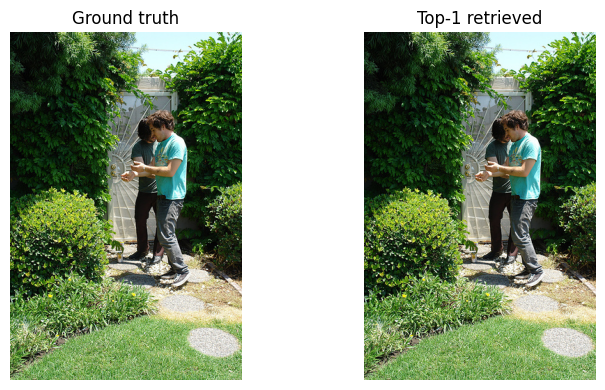

Query caption: Two young , White males are outside near many bushes .
Ground-truth image_id: 1000092795.jpg
Top retrieved image_id: 1000092795.jpg
Score: 0.3109


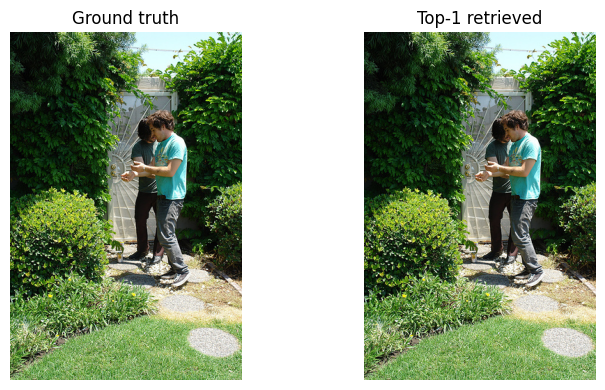

Query caption: Two men in green shirts are standing in a yard .
Ground-truth image_id: 1000092795.jpg
Top retrieved image_id: 1000092795.jpg
Score: 0.3287


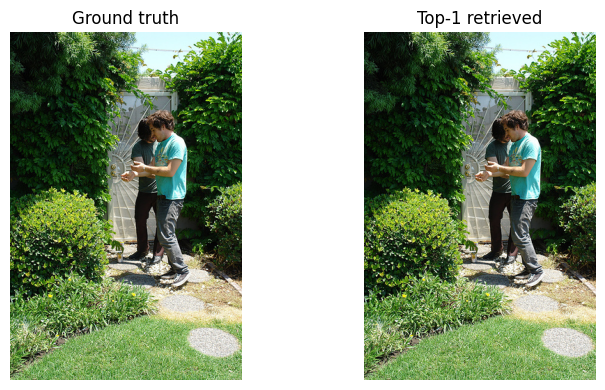

In [7]:
rankings = np.argsort(similarity, axis=1)[:, ::-1]
top1_indices = rankings[:, 0]
top5_indices = rankings[:, :5]

success_mask = np.any(top5_indices == gt_indices[:, None], axis=1)
success_query_indices = np.where(success_mask)[0][:3]


def show_image_pair(left_item, right_item, left_title, right_title):
    """Hien thi hai anh canh nhau de so sanh."""
    left_image = Image.open(PROJECT_ROOT / left_item["image_path"]).convert("RGB")
    right_image = Image.open(PROJECT_ROOT / right_item["image_path"]).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(left_image)
    axes[0].set_title(left_title)
    axes[0].axis("off")

    axes[1].imshow(right_image)
    axes[1].set_title(right_title)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


for query_idx in success_query_indices:
    gt_idx = gt_indices[query_idx]
    top_idx = top1_indices[query_idx]
    score = similarity[query_idx, top_idx]

    print("=" * 80)
    print(f"Query caption: {captions[query_idx]}")
    print(f"Ground-truth image_id: {subset_metadata[gt_idx]['image_id']}")
    print(f"Top retrieved image_id: {subset_metadata[top_idx]['image_id']}")
    print(f"Score: {score:.4f}")

    show_image_pair(
        subset_metadata[gt_idx],
        subset_metadata[top_idx],
        "Ground truth",
        "Top-1 retrieved",
    )

## 8. Analyze some failure cases

Query caption: Two friends enjoy time spent together .
Ground-truth image_id: 1000092795.jpg
Top-5 retrieved:
#1 1056415186.jpg | score=0.2800
#2 1258371874.jpg | score=0.2779
#3 125635185.jpg | score=0.2751
#4 1131804997.jpg | score=0.2748
#5 1177994172.jpg | score=0.2723


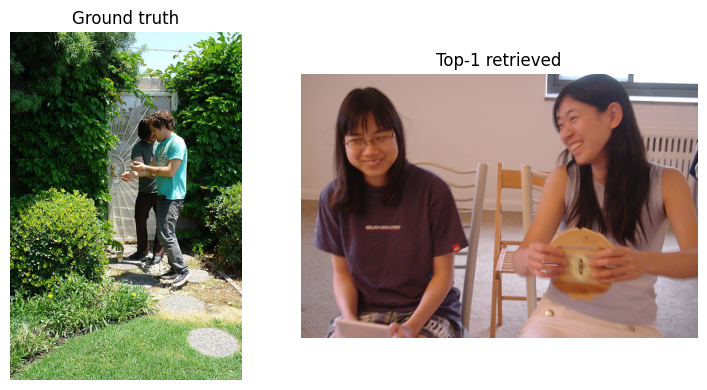

Query caption: Two men working on a machine wearing hard hats .
Ground-truth image_id: 10002456.jpg
Top-5 retrieved:
#1 11220707.jpg | score=0.3066
#2 1055753357.jpg | score=0.3004
#3 116569042.jpg | score=0.2946
#4 106372282.jpg | score=0.2932
#5 116569046.jpg | score=0.2920


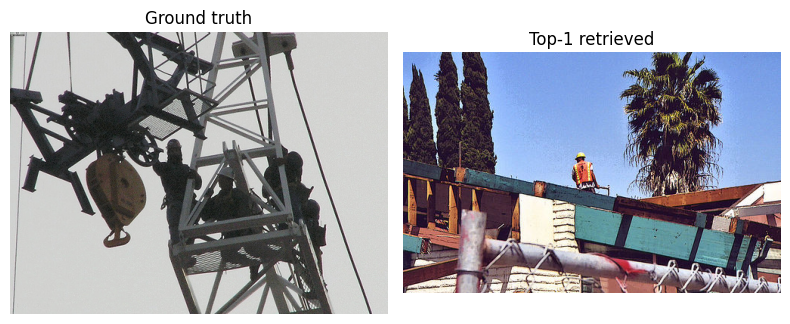

Query caption: a guy stitching up another man 's coat .
Ground-truth image_id: 1000523639.jpg
Top-5 retrieved:
#1 10751489.jpg | score=0.2711
#2 11382381.jpg | score=0.2690
#3 110983128.jpg | score=0.2685
#4 126238618.jpg | score=0.2680
#5 129978192.jpg | score=0.2670


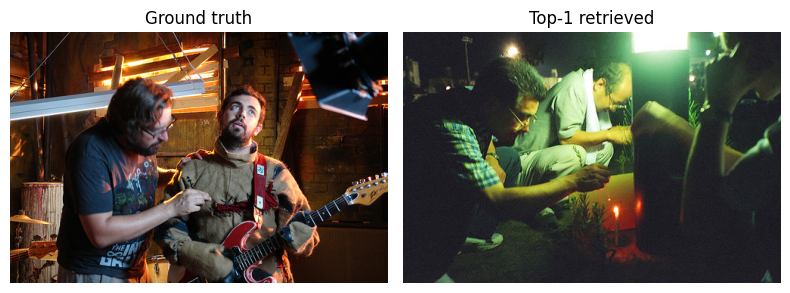

In [8]:
top10_indices = rankings[:, :10]
failure_mask = ~np.any(top10_indices == gt_indices[:, None], axis=1)
failure_query_indices = np.where(failure_mask)[0][:3]

if len(failure_query_indices) == 0:
    print("Khong tim thay failure case voi dieu kien ground-truth khong nam trong top-10.")

for query_idx in failure_query_indices:
    gt_idx = gt_indices[query_idx]
    top_idx = top1_indices[query_idx]

    print("=" * 80)
    print(f"Query caption: {captions[query_idx]}")
    print(f"Ground-truth image_id: {subset_metadata[gt_idx]['image_id']}")
    print("Top-5 retrieved:")

    for rank, retrieved_idx in enumerate(rankings[query_idx, :5], start=1):
        print(
            f"#{rank} {subset_metadata[retrieved_idx]['image_id']} | "
            f"score={similarity[query_idx, retrieved_idx]:.4f}"
        )

    show_image_pair(
        subset_metadata[gt_idx],
        subset_metadata[top_idx],
        "Ground truth",
        "Top-1 retrieved",
    )